<p><font color="blue">
    <h3 align="center">Laboratoire d'Etudes Statistiques et de Conception d'Applications et Logiciels</h3>
    <h1 align="center">L.E.S.C.A.L.</h3>
    <h1 align="center">--------------------------------------</h3>
    <h2 align="center">Cedoriase Academy For Artificial Intelligence</h2>
    <h4 align="center">+229 66233516 / cedoriaseacademy@lescal-soc.com</h4>
    <h1 align="center">--------------------------------------</h3>
    <h2 align="center">Analyse exploratoire de données - Partie 2</h2>
    <h1 align="center">--------------------------------------</h3>
    <h2 align="center">Visualisation des données</h2>
</font></p>

!pip install seaborn # Windows

!python3 -m pip install seaborn # Linux

In [1]:
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt

import seaborn as sns

sns.set()

# Les graphiques au format Retina sont plus nets et lisibles
%config InlineBackend.figure_format = 'retina'

In [2]:
# importation des données
df= pd.read_csv("telecom_churn.csv", delimiter= ";")
df.head(10)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False
5,AL,118,510,Yes,No,0,223.4,98,37.98,220.6,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False
6,MA,121,510,No,Yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,False
7,MO,147,415,Yes,No,0,157.0,79,26.69,103.1,94,8.76,211.8,96,9.53,7.1,6,1.92,0,False
8,LA,117,408,No,No,0,184.5,97,31.37,351.6,80,29.89,215.8,90,9.71,8.7,4,2.35,1,False
9,WV,141,415,Yes,Yes,37,258.6,84,43.96,222.0,111,18.87,326.4,97,14.69,11.2,5,3.02,0,False


### 1- Variables quantitatives

### Histogrammes

NB : 

- Total day minutes = Nbre total de minutes d'appels effectués en journée

- Total intl calls = Nbre total d'appels effectués vers l'international


array([[<Axes: title={'center': 'Total day minutes'}>,
        <Axes: title={'center': 'Total intl calls'}>]], dtype=object)

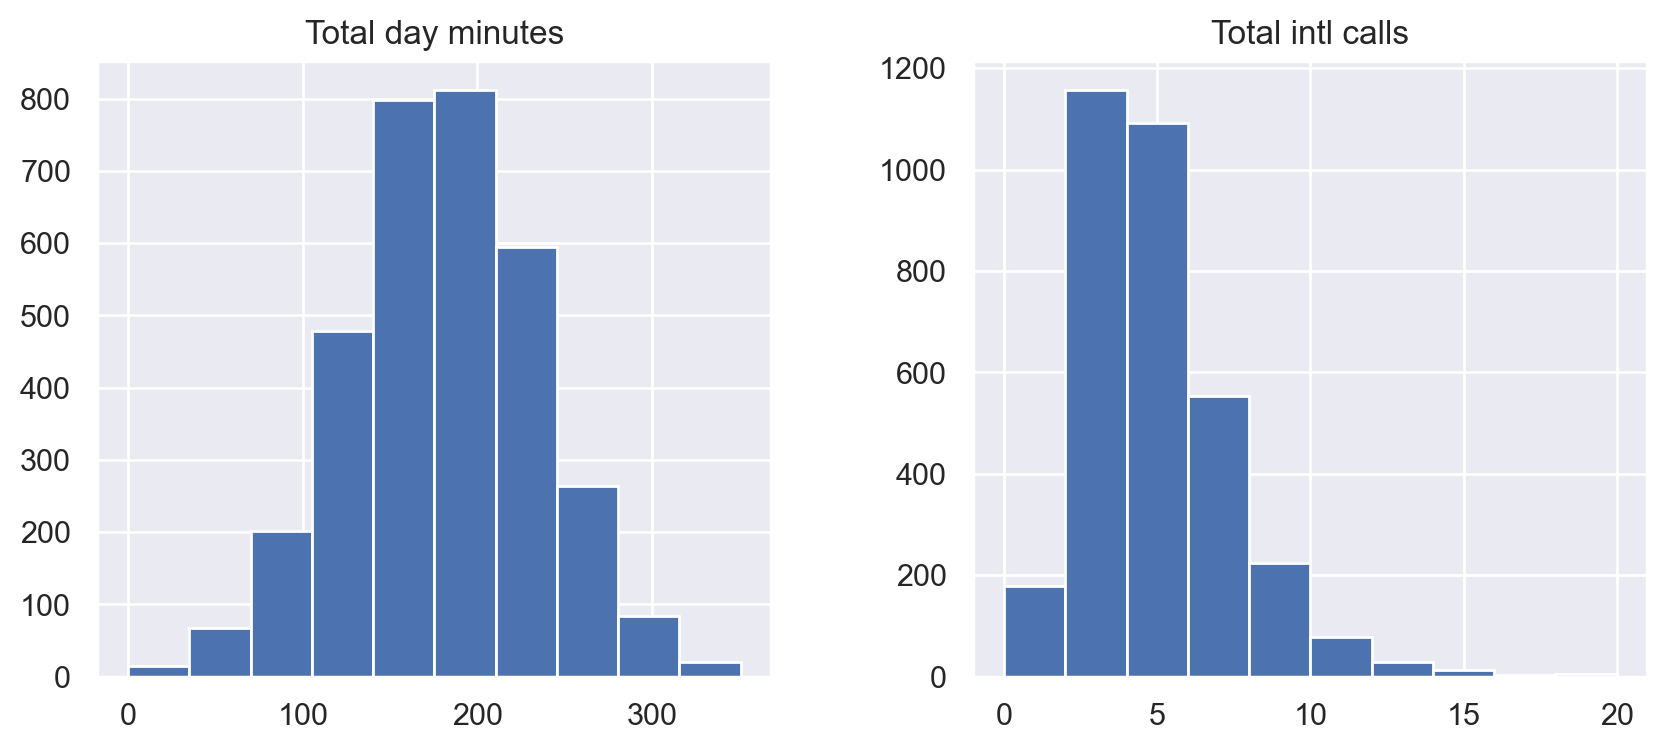

In [3]:
features= ["Total day minutes",
          "Total intl calls"]
df[features].hist(figsize= (10,4) )

### Histogrammes avec seaborn

<Axes: xlabel='Total intl calls', ylabel='Density'>

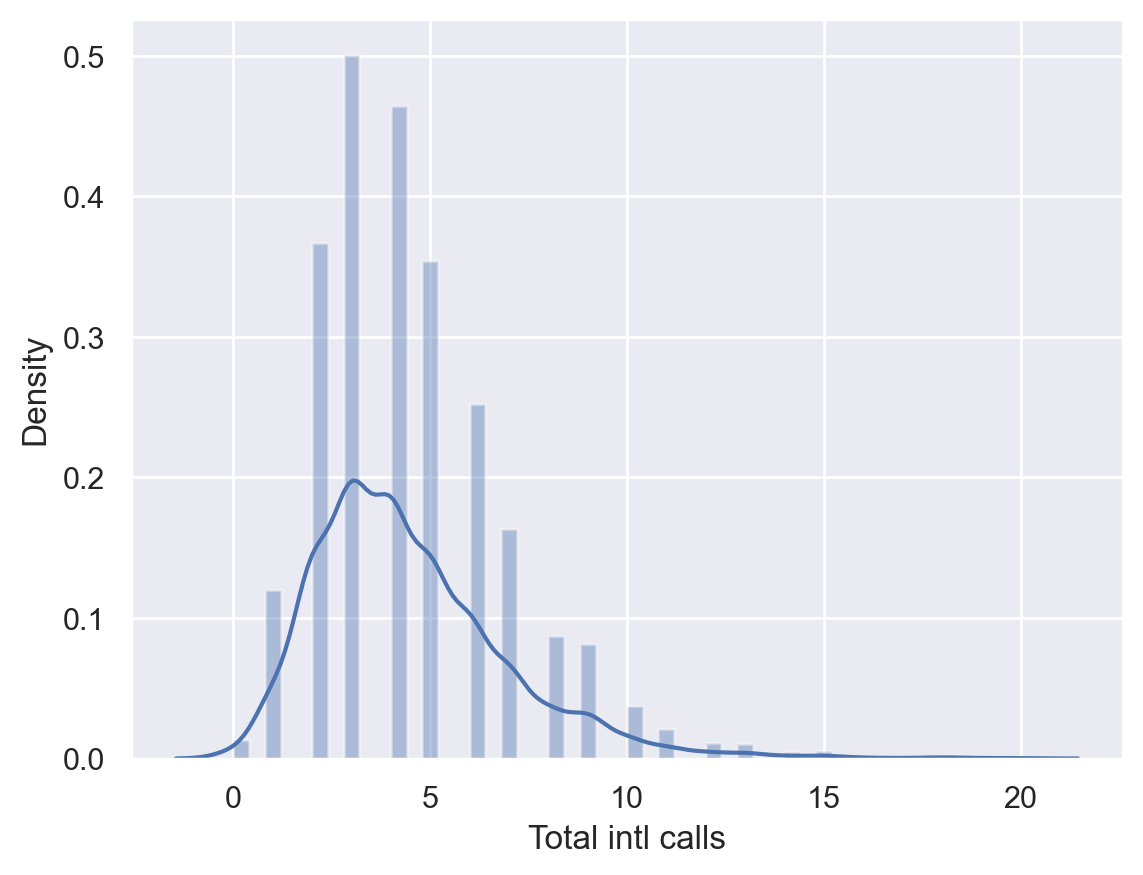

In [4]:
sns.distplot(df["Total intl calls"])

### Boxplot

<Axes: ylabel='Total intl calls'>

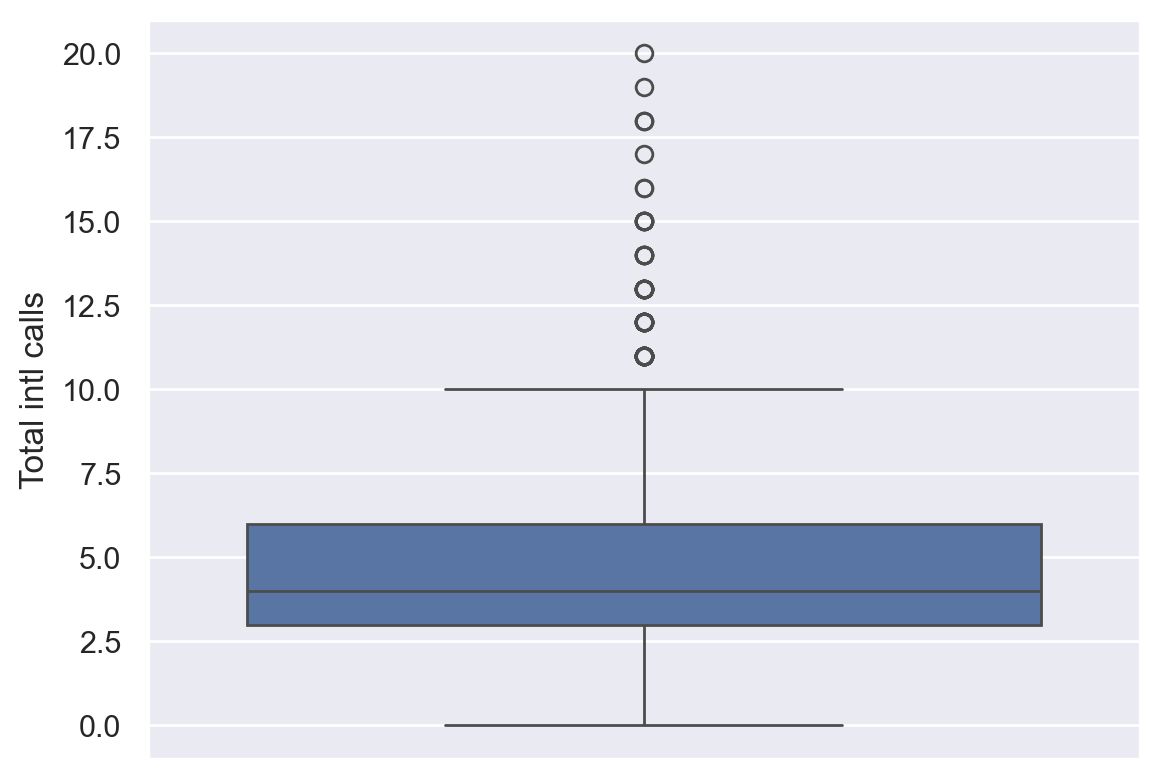

In [5]:
sns.boxplot(y= "Total intl calls", data= df)

### Statistiques descriptives relatives aux deux variables de l'objet features

In [6]:
df[features]

,Total day minutes,Total intl calls
0,265.1,3
1,161.6,3
2,243.4,5
3,299.4,7
4,166.7,3
...,...,...
3328,156.2,6
3329,231.1,4
3330,180.8,6
3331,213.8,10


### 2- Variables qualitatives

### Tableau des effectifs de la variable Churn

In [7]:
df["Churn"].value_counts() 

Churn
False    2850
True      483
Name: count, dtype: int64

### Diagramme en bandes

NB :

- Churn : Résiliation (False si abonné fidèle; True si abonné ayant résilié)

- Customer service calls : nbre d'appels effectués à l'endroit du service clientèle 

<Axes: xlabel='Customer service calls', ylabel='count'>

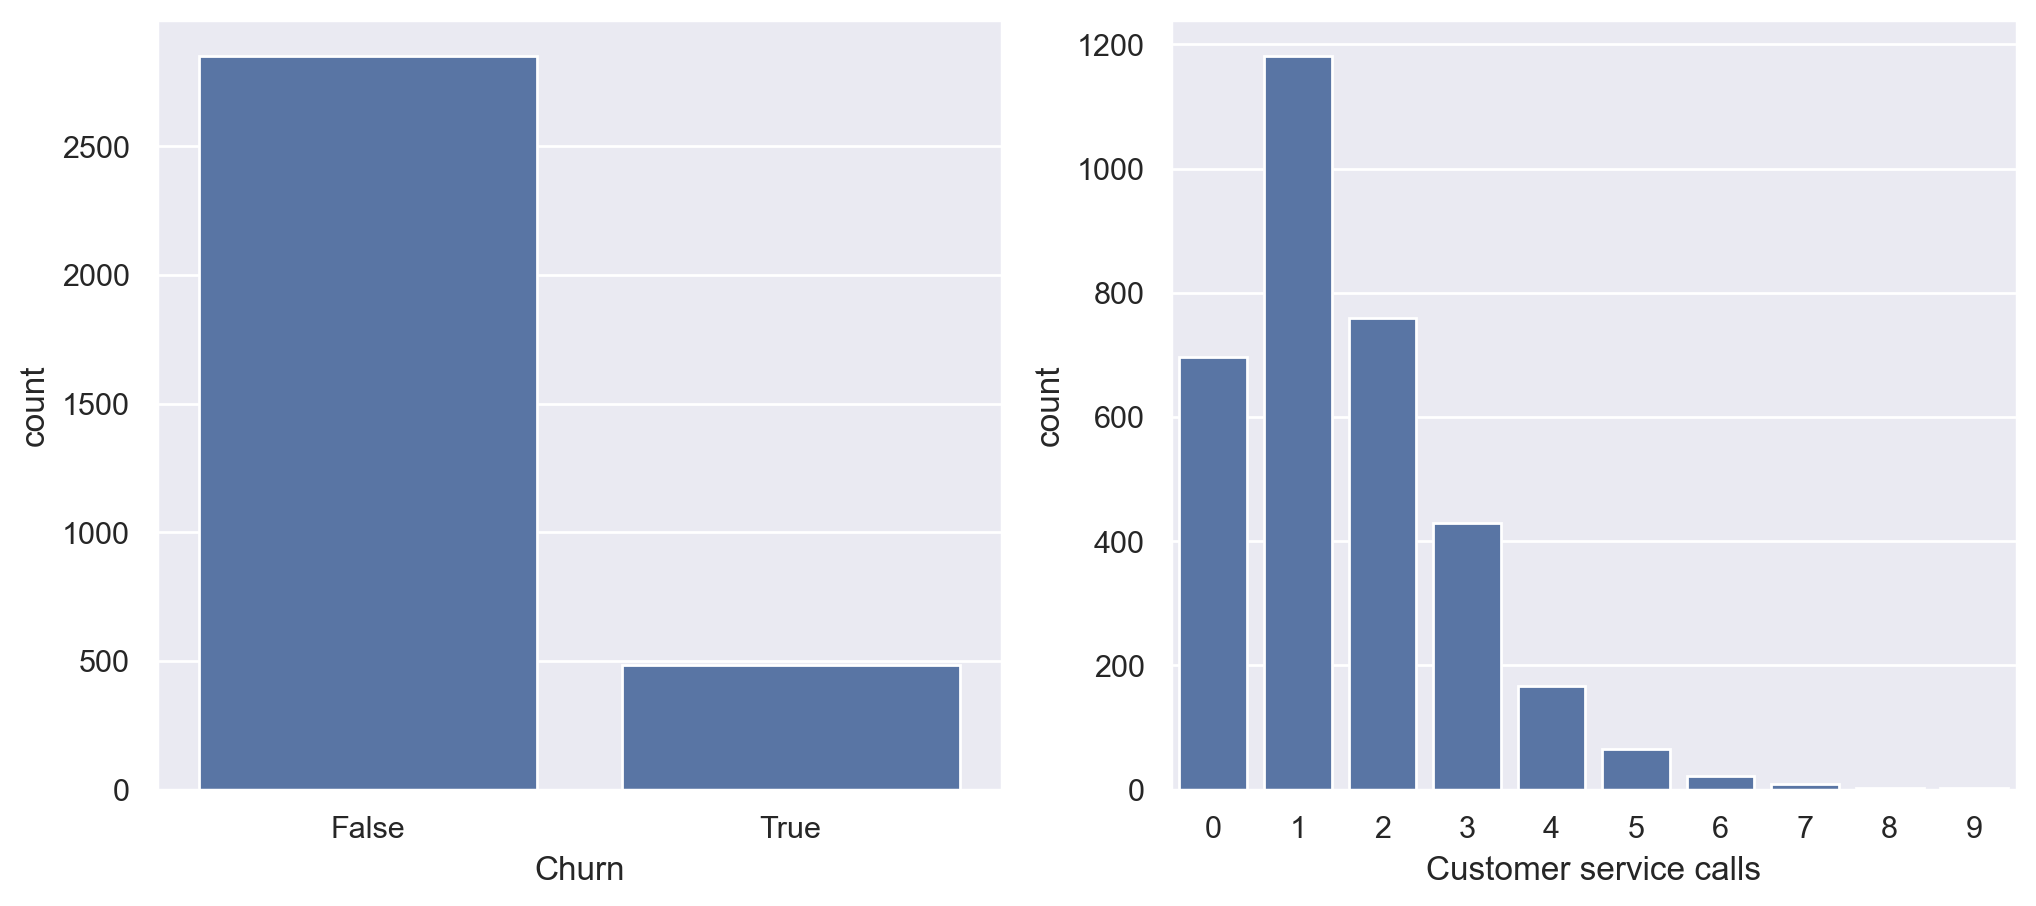

In [8]:
fig,axes= plt.subplots(nrows= 1, ncols= 2, figsize= (12,5) ) #figure ploib à 1 row 2 cols 
sns.countplot(x= "Churn", data= df,ax= axes[0] )
sns.countplot(x= "Customer service calls", data= df,ax= axes[1] )

### 3- Diagrammes multivariés

Les diagrammes multivariés nous permettent de voir les relations entre deux ou plusieurs variables différentes, le tout sur une seule figure. 

### 3.1- Visualisation entre plusieurs variables quantitatives

### La Matrice de corrélation

Elle permet de connaître la nature des liaisons entre les variables quantitatives

Examinons les corrélations entre les variables numériques de notre ensemble de données.

In [9]:
numerical= list(
    set(df.columns)-{
        "State", "International plan", "Voice mail plan","Area code", "Churn", "Customer service calls" 
    }
)

numerical

['Total night calls',
 'Number vmail messages',
 'Total intl calls',
 'Total night charge',
 'Total day charge',
 'Total day minutes',
 'Total eve calls',
 'Total day calls',
 'Total intl minutes',
 'Total eve minutes',
 'Account length',
 'Total night minutes',
 'Total intl charge',
 'Total eve charge']

### Calcul et représentation des corrélations

Nous utilisons la méthode corr() qui calcule le coefficient de corrélation entre chaque paire de variables quantitatives. 

In [10]:
corr_matrix= df[numerical].corr()
corr_matrix

,Total night calls,Number vmail messages,Total intl calls,Total night charge,Total day charge,Total day minutes,Total eve calls,Total day calls,Total intl minutes,Total eve minutes,Account length,Total night minutes,Total intl charge,Total eve charge
Total night calls,1.000000,0.007123,0.000305,0.011188,0.022972,0.022972,0.007710,-0.019557,-0.013605,0.007586,-0.013176,0.011204,-0.013630,0.007596
Number vmail messages,0.007123,1.000000,0.013957,0.007663,0.000776,0.000778,-0.005864,-0.009548,0.002856,0.017562,-0.004628,0.007681,0.002884,0.017578
Total intl calls,0.000305,0.013957,1.000000,-0.012329,0.008032,0.008033,0.017434,0.004574,0.032304,0.002541,0.020661,-0.012353,0.032372,0.002541
Total night charge,0.011188,0.007663,-0.012329,1.000000,0.004301,0.004300,-0.002056,0.022927,-0.015214,-0.012593,-0.008960,0.999999,-0.015186,-0.012601
Total day charge,0.022972,0.000776,0.008032,0.004301,1.000000,1.000000,0.015769,0.006753,-0.010157,0.007050,0.006214,0.004324,-0.010094,0.007036
Total day minutes,0.022972,0.000778,0.008033,0.004300,1.000000,1.000000,0.015769,0.006750,-0.010155,0.007043,0.006216,0.004323,-0.010092,0.007029
Total eve calls,0.007710,-0.005864,0.017434,-0.002056,0.015769,0.015769,1.000000,0.006462,0.008703,-0.011430,0.019260,-0.002093,0.008674,-0.011423
Total day calls,-0.019557,-0.009548,0.004574,0.022927,0.006753,0.006750,0.006462,1.000000,0.021565,-0.021451,0.038470,0.022938,0.021666,-0.021449
Total intl minutes,-0.013605,0.002856,0.032304,-0.015214,-0.010157,-0.010155,0.008703,0.021565,1.000000,-0.011035,0.009514,-0.015207,0.999993,-0.011043
Total eve minutes,0.007586,0.017562,0.002541,-0.012593,0.007050,0.007043,-0.011430,-0.021451,-0.011035,1.000000,-0.006757,-0.012584,-0.011067,1.000000


Ensuite, nous transmettons la matrice de corrélation résultante à heatmap() de seaborn, qui affiche une matrice codée par couleur selon les corrélations obtenues

<Axes: >

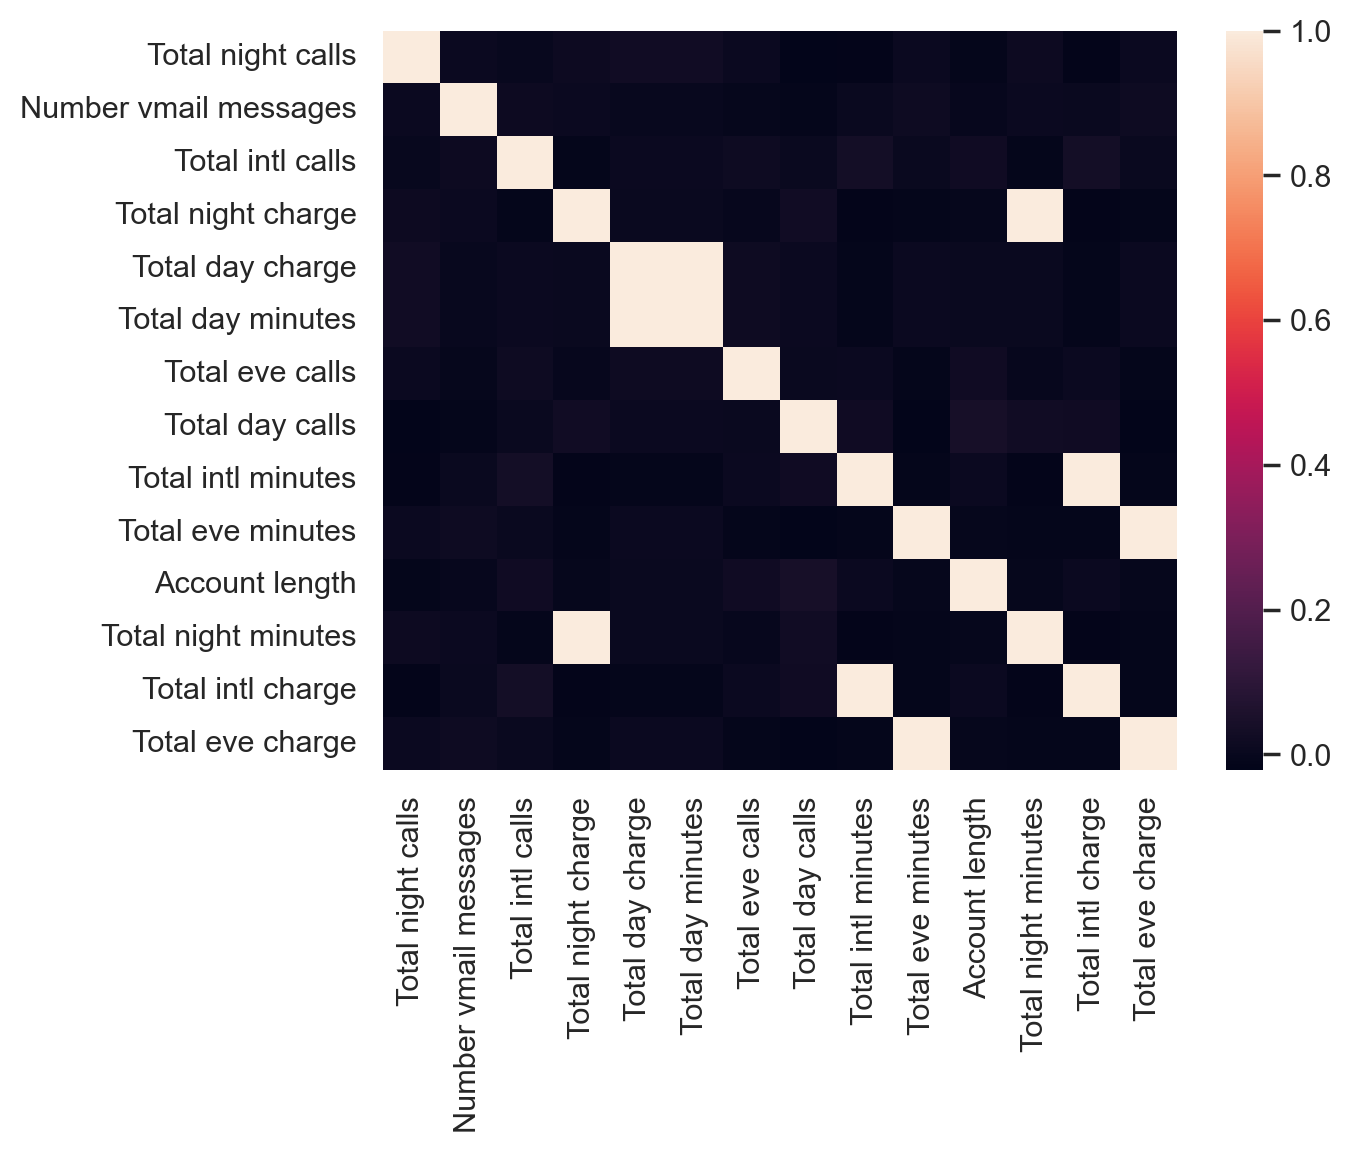

In [11]:
sns.heatmap(corr_matrix)

### Le Nuage de points

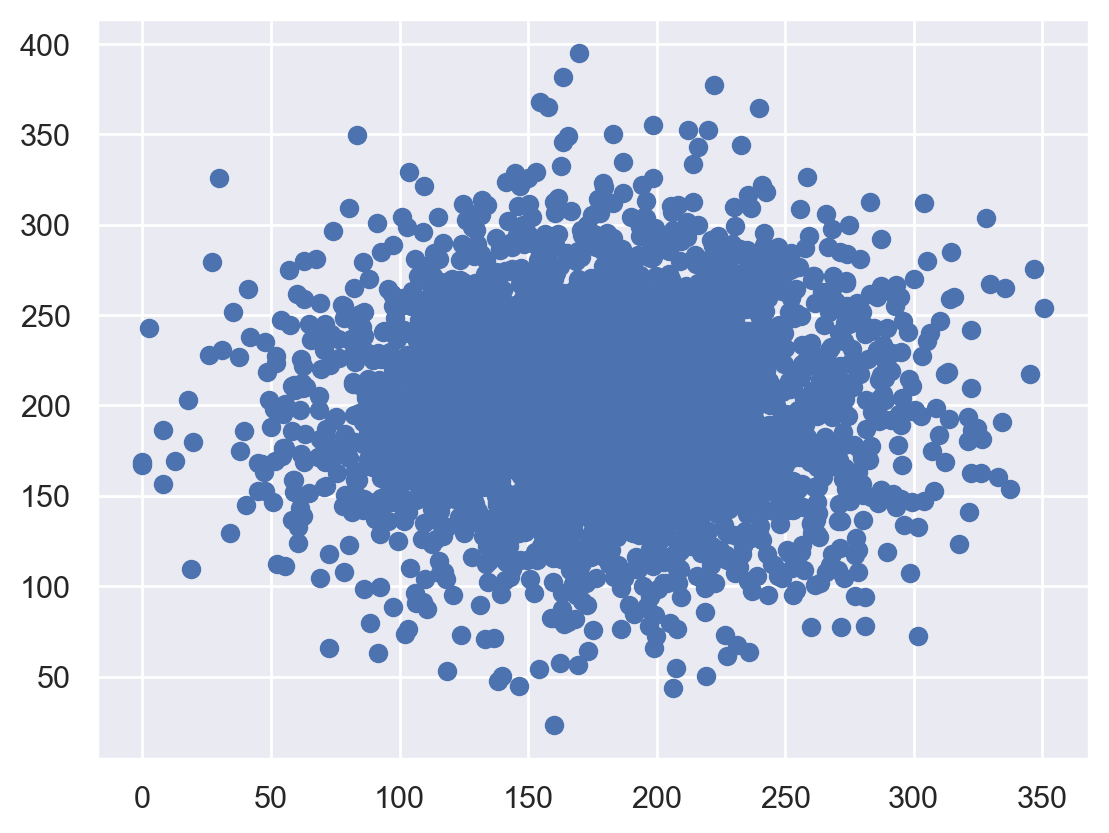

In [12]:
plt.scatter(df["Total day minutes"], df["Total night minutes"] )

Nous obtenons une image inintéressante de deux variables distribuées normalement. De plus, il semble que ces caractéristiques ne soient pas corrélées car la forme elliptique obtenue est alignée avec les axes.

Il existe une option un peu plus sophistiquée pour créer un nuage de points avec la bibliothèque Seaborn :

La fonction jointplot() trace deux histogrammes qui peuvent être utiles dans certains cas.

### La Matrice du nuage de points

Elle permet de visualiser les corrélations entre variables numériques. Sa diagonale contient les distributions des variables correspondantes, et les nuages de points pour chaque paire de variables remplissent le reste de la matrice.

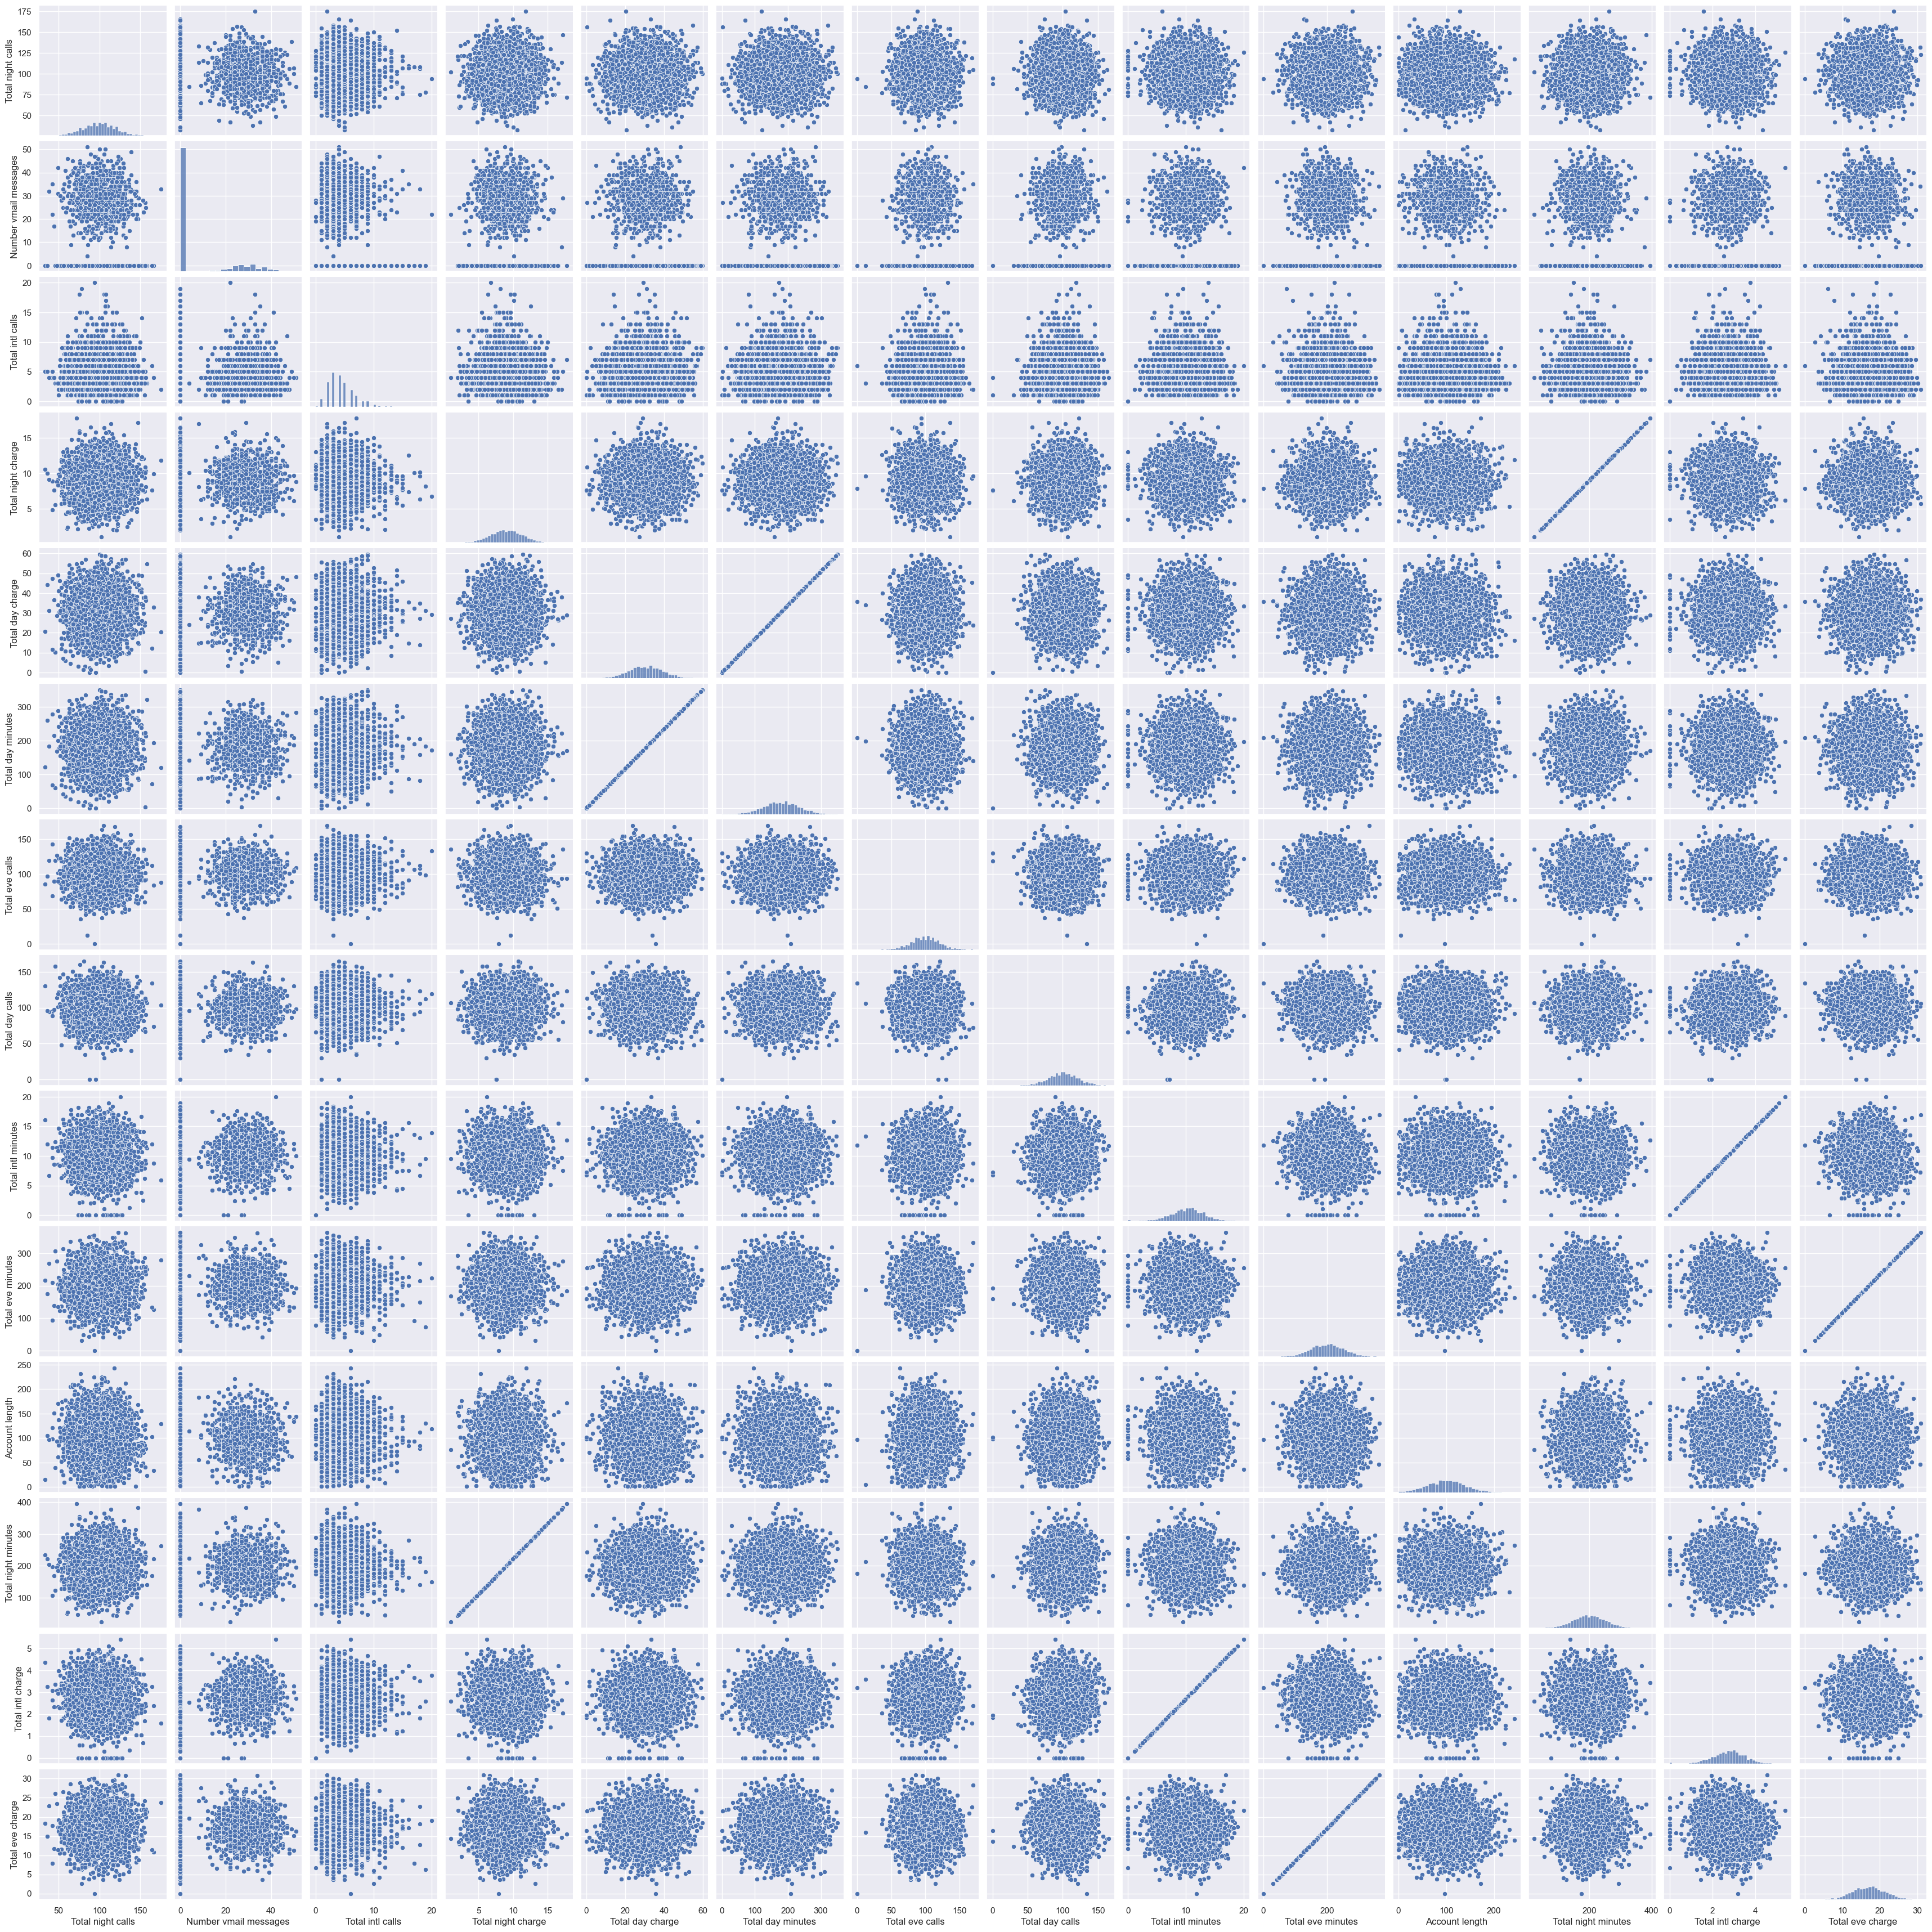

In [13]:
%config InlineBackend.figure_format= "png"
sns.pairplot(df[numerical])

### 3.2- Visualisation entre variables quantitative et qualitative

a - Nuage de points du nbre total de minutes d'appels effectués la nuit en fonction du nbre total de minutes d'appels effectués le jour selon le type d'abonné (abonné fidèle et abonné ayant résilié)

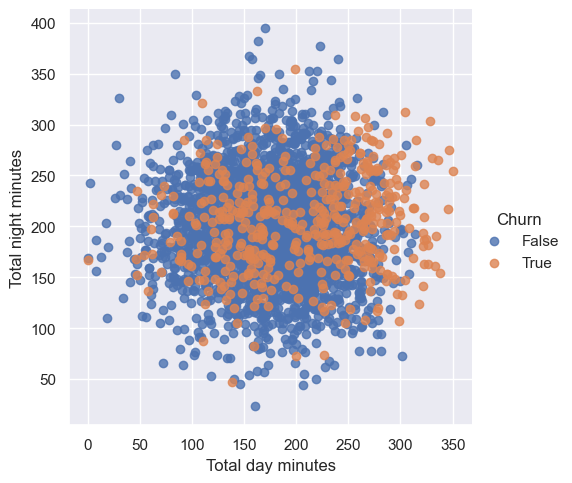

In [14]:
var_quart= ["Total day minutes",
            "Total night minutes"]
sns.lmplot(data= df,
           x= "Total day minutes", y= "Total night minutes", 
           hue="Churn", fit_reg= False )

b- Histogramme de la variable nombre d'appels à l'endroit du service clientèle en fonction du type d'abonné

Interprétation : Par opposition aux abonnés ayant résilié, les abonnés fidèles appellent plus le service clientèle

### 3.3- Visualisation entre plusieurs variables qualitatives

### Diagramme en bandes

#### Examinons la relation entre le taux de résiliation et les variables binaires (à 2 modalités) : le forfait international et le forfait de messagerie vocale.

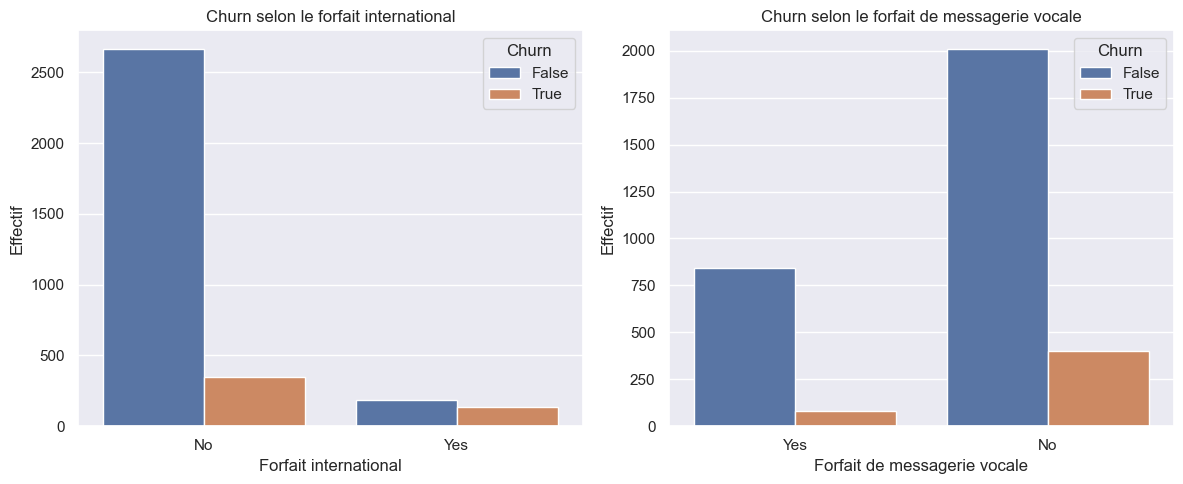

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(
     data=df,
     x="International plan",
     hue="Churn",
     ax=axes[0]
)
axes[0].set_title("Churn selon le forfait international")
axes[0].set_xlabel("Forfait international")
axes[0].set_ylabel("Effectif")

sns.countplot(
     data=df,
     x="Voice mail plan",
     hue="Churn",
     ax=axes[1]
)
axes[1].set_title("Churn selon le forfait de messagerie vocale")
axes[1].set_xlabel("Forfait de messagerie vocale")
axes[1].set_ylabel("Effectif")

plt.tight_layout()

Interprétation :

**Variable Forfait inernational**

- Très peu d'abonnés fidèles activent de forfait international

- Pareil pour les abonnés ayant résilié



**Variable Forfait de messagerie vocale**

- Peu d'abonnés fidèles activent le forfait de messagerie vocale

- Pareil pour les abonnés ayant résilié

### Tableau de contingence

Il est issu du croisement entre deux variables qualitatives

- Regardons les liaisons entre les variables qualitatives Churn et State en créant un tableau de contingence

In [22]:
table_contingence = pd.crosstab(df["State"], df["Churn"])
table_contingence.head(10)

Churn,False,True
State,,
AK,49,3
AL,72,8
AR,44,11
AZ,60,4
CA,25,9
CO,57,9
CT,62,12
DC,49,5
DE,52,9


- On peut transposer le tableau

In [23]:
table_contingence.T

State,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Churn,,,,,,,,,,,,,,,,,,,,,
False,49,72,44,60,25,57,62,49,52,55,...,52,48,54,62,72,65,52,71,96,68
True,3,8,11,4,9,9,12,5,9,8,...,8,5,18,10,5,8,14,7,10,9


### Calculons le taux de résiliation dans chaque état, en le triant par ordre décroissant

In [24]:
taux_resiliation = (
     table_contingence[True]
     .div(table_contingence.sum(axis=1))
     .mul(100)
     .sort_values(ascending=False)
     .rename("Taux de résiliation (%)")
)

taux_resiliation    

State
NJ    26.470588
CA    26.470588
TX    25.000000
MD    24.285714
SC    23.333333
MI    21.917808
MS    21.538462
NV    21.212121
WA    21.212121
ME    20.967742
MT    20.588235
AR    20.000000
KS    18.571429
NY    18.072289
MN    17.857143
PA    17.777778
MA    16.923077
CT    16.216216
NC    16.176471
NH    16.071429
GA    14.814815
DE    14.754098
OK    14.754098
OR    14.102564
UT    13.888889
CO    13.636364
KY    13.559322
SD    13.333333
OH    12.820513
FL    12.698413
IN    12.676056
ID    12.328767
WY    11.688312
MO    11.111111
VT    10.958904
AL    10.000000
NM     9.677419
ND     9.677419
WV     9.433962
TN     9.433962
DC     9.259259
RI     9.230769
WI     8.974359
IL     8.620690
NE     8.196721
LA     7.843137
IA     6.818182
VA     6.493506
AZ     6.250000
AK     5.769231
HI     5.660377
Name: Taux de résiliation (%), dtype: float64